In [20]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Load dataset
iris = load_iris()
X = iris.data[:, :2]   # use only 2 features for easy visualization
print(X[:5])

[[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]]


In [21]:
print((np.random.choice(len(X), 3, replace=False)))
X_selected = X[np.random.choice(len(X), 3, replace=False)]
print(X_selected)

[84 20 45]
[[6.5 2.8]
 [6.1 2.8]
 [7.7 3.8]]


In [22]:
def kmeans(X, k, max_iter=100):
    
    # Step 1: Random centroids
    np.random.seed(42)
    centroids = X[np.random.choice(len(X), k, replace=False)]
    
    for _ in range(max_iter):
        
        # Step 2: Assign clusters
        clusters = []
        for point in X:
            distances = np.sqrt(np.sum((centroids - point)**2, axis=1))
            cluster = np.argmin(distances) #argmin returns the index of the minimum value
            clusters.append(cluster)
        
        clusters = np.array(clusters)
        # print(clusters[:10])  # print first 10 cluster assignments
        
        # Step 3: Update centroids
        new_centroids = []
        for i in range(k):
            new_centroids.append(X[clusters == i].mean(axis=0)) # X[clusters == i] selects all points in cluster i, then we take the mean to get the new centroid
        
        new_centroids = np.array(new_centroids)
        
        # Stop if no change
        if np.all(centroids == new_centroids):
            break
        
        centroids = new_centroids
    
    return clusters, centroids

clusters, centroids = kmeans(X, k=3)
print("Final Centroids:\n", centroids)


Final Centroids:
 [[5.8        2.7       ]
 [5.00392157 3.40980392]
 [6.82391304 3.07826087]]


[1 1 1 1 1 1 1 1 1 1]
Final Centroids:
 [[5.8        2.7       ]
 [5.00392157 3.40980392]
 [6.82391304 3.07826087]]


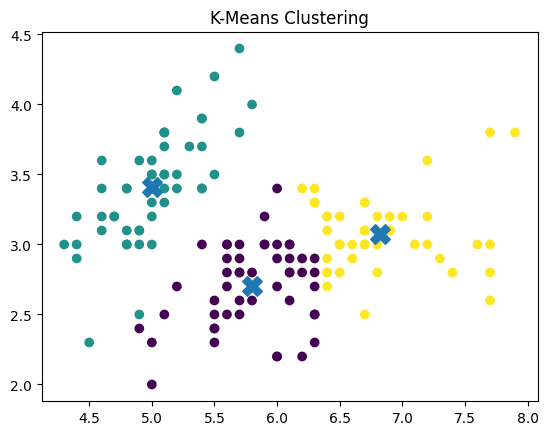

In [23]:
k = 3
clusters, centroids = kmeans(X, k)
print(clusters[:10])  # print first 10 cluster assignments
print("Final Centroids:\n", centroids)

# Plot
plt.scatter(X[:,0], X[:,1], c=clusters)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)
plt.title("K-Means Clustering")
plt.show()

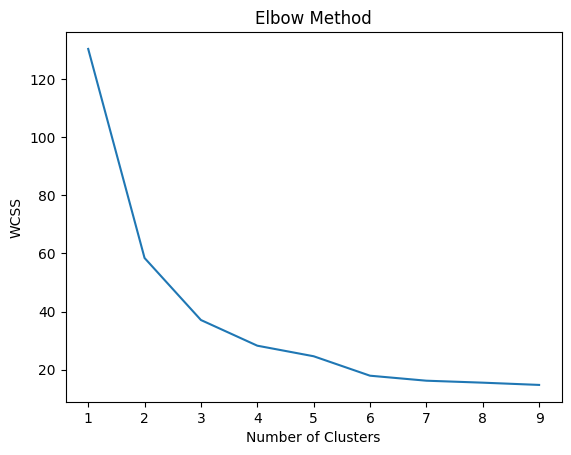

In [24]:
wcss = []

for k in range(1, 10):
    clusters, centroids = kmeans(X, k)
    
    total = 0
    for i, point in enumerate(X):
        total += np.sum((point - centroids[clusters[i]])**2)
    
    wcss.append(total)

plt.plot(range(1,10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [25]:
for k in range(2, 6):
    clusters, centroids = kmeans(X, k)
    score = silhouette_score(X, clusters)
    print("K =", k, "Silhouette Score =", score)

K = 2 Silhouette Score = 0.4644681851183547
K = 3 Silhouette Score = 0.44237257041388633
K = 4 Silhouette Score = 0.4178487707702818
K = 5 Silhouette Score = 0.3881660561504278


In [26]:
def manual_silhouette(X, clusters):
    
    n = len(X)
    unique_clusters = np.unique(clusters)
    silhouette_values = []
    
    for i in range(n):
        
        same_cluster = X[clusters == clusters[i]]
        other_clusters = unique_clusters[unique_clusters != clusters[i]]
        
        # -------- a (intra-cluster distance) --------
        a = 0
        if len(same_cluster) > 1:
            distances = []
            for point in same_cluster:
                if not np.array_equal(point, X[i]):
                    dist = np.sqrt(np.sum((X[i] - point)**2))
                    distances.append(dist)
            a = np.mean(distances)
        
        # -------- b (nearest cluster distance) --------
        b_values = []
        
        for cluster in other_clusters:
            cluster_points = X[clusters == cluster]
            distances = []
            
            for point in cluster_points:
                dist = np.sqrt(np.sum((X[i] - point)**2))
                distances.append(dist)
            
            b_values.append(np.mean(distances))
        
        b = min(b_values)
        
        # Silhouette value for this point
        s = (b - a) / max(a, b)
        silhouette_values.append(s)
    
    # Final score
    return np.mean(silhouette_values)

In [27]:
for k in range(2, 6):
    clusters, centroids = kmeans(X, k)
    score = manual_silhouette(X, clusters)
    print("K =", k, "Manual Silhouette Score =", score)

K = 2 Manual Silhouette Score = 0.46053084689220003
K = 3 Manual Silhouette Score = 0.4367975495607482
K = 4 Manual Silhouette Score = 0.4086110477781265
K = 5 Manual Silhouette Score = 0.37771360096850826
